In [1]:
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import os
from sqlalchemy import create_engine

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
ld = '''SELECT orv.review_score, o.order_delivered_customer_date AS dd,o.order_estimated_delivery_date AS edt
        FROM orders AS o
        INNER JOIN order_reviews AS orv
        ON o.order_id = orv.order_id
        WHERE o.order_status = 'delivered'; '''
ld_df = pd.read_sql(ld,engine)


In [3]:
ld_df['delivery_gap'] = (ld_df['edt'] - ld_df['dd']).dt.days
ld_df.drop(['dd','edt'],axis=1,inplace=True)


Now we have a dataframe showing delivery gap with review scores

In [4]:
avg_gap_df = ld_df.groupby(ld_df['review_score']).agg(avg_gap=('delivery_gap','mean')).round(2).reset_index()

avg_gap_df shows us average delivery gap aggregated according to the review score

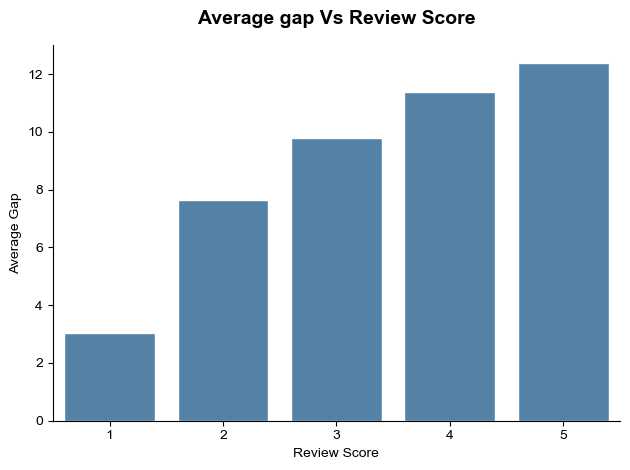

In [5]:
fig,ax = plt.subplots()
sns.set_style('ticks')
sns.barplot(x='review_score',y='avg_gap',data=avg_gap_df,color='steelblue')
ax.set_title('Average gap Vs Review Score',fontsize=14,weight='bold',pad=15)
ax.set_xlabel('Review Score')
ax.set_ylabel('Average Gap')
sns.despine()
plt.tight_layout()
plt.show()

Average gap is the number of days between estimated delivery date and actual delivery date (late delivery = negative gap) <br>
We can see that faster delivery is associated with positive order reviews as delivery gap rises with the review score.<br>
One interesting fact here is that the jump in average gap is largest from 1>2 review score after which the effect of late delivery on review score fades.

In [6]:
# Exporting dataframe to csv for use in Tableau
avg_gap_df.to_csv('/Volumes/Air/Olist_exports_tableau/Delivery_gap_rating.csv', index=False)